# Module 05: Probabilities, Samples, and Statistical Inference

---

## 🎓 The Final Piece of the Puzzle

**Where this comes from:** Course 01 (AIAT 111) — Unit 2, lesson 04 "Probabilistic Reasoning: Bayes' Theorem" applied Bayes to single events, and Course 02 (AIAT 112) — Unit 3 reasoned under uncertainty with Bayesian networks and HMMs. Both handed you the probabilities. Module 05 is where you learn to estimate them from data and say how confident you are entitled to be.

**Congratulations on reaching the final module!** This module integrates everything you've learned:

- **From Module 01**: Data representation as vectors/matrices for probabilistic models
- **From Module 03**: Statistical foundations → Extended to **statistical inference**
- **From Module 04**: Evaluating reduced-dimensional representations statistically

> 💡 **Complete Picture**: Now you can:
> - Represent data (Module 01)
> - Train models with optimization (Module 03, using gradients from Module 02)
> - Reduce dimensions efficiently (Module 04)
> - Evaluate and make predictions with confidence (Module 05)

**You're now ready to apply all these concepts to real ML projects!**

---

## Learning Objectives

In this module, you will learn:
- Probability theory and distributions for ML
- Random variables and sampling techniques
- Statistical inference methods
- Hypothesis testing for model evaluation
- Bayesian inference concepts
- Applying probabilistic models to ML problems

---


---

## 📌 Real case: Google Flu Trends, and the number nobody put an interval around

In 2008 Google launched **Google Flu Trends**, which estimated influenza activity from the volume of
flu-related search queries. It was fast, it was free, it appeared to track the US Centers for Disease
Control's own surveillance closely, and it became the standard example of what large-scale data could do
that traditional statistics could not.

Then it failed, publicly. It missed the 2009 H1N1 pandemic. And in **February 2013**, as David Lazer, Ryan
Kennedy, Gary King and Alessandro Vespignani open their *Science* paper **"The Parable of Google Flu: Traps
in Big Data Analysis"** (2014): "*Nature* reported that GFT was predicting **more than double the proportion
of doctor visits for influenza-like illness (ILI) than the Centers for Disease Control and Prevention* —
which bases its estimates on surveillance reports from laboratories across the United States. This happened
despite the fact that GFT was built to predict CDC reports." Part of the diagnosis: the model was
aggregating queries about different health conditions, so it drifted as search behaviour changed — and
nothing in the published output said how uncertain any given week's estimate was.

**What goes wrong without this.** A model that reports one number reports no doubt, and a number with no
doubt attached invites decisions it cannot support. Every technique in this module exists to attach the
doubt: confidence intervals for "how sure are we", hypothesis tests for "is this difference real", Bayes'
rule for "what does this evidence actually change".


# Part 1: WHY

## Understanding the Motivation

### Why do Probabilities and Statistical Inference matter for Machine Learning?

Probability and statistics are fundamental to understanding ML:

- **Uncertainty**: ML models make predictions with uncertainty that we need to quantify
- **Data Sampling**: Understanding sampling helps with train/test splits and cross-validation
- **Model Evaluation**: Statistical tests help determine if model improvements are significant
- **Bayesian Methods**: Many ML algorithms use probabilistic frameworks
- **Decision Making**: Probabilities help make informed decisions from model outputs

### Real-World Applications

- **Confidence Intervals**: Understanding prediction uncertainty
- **A/B Testing**: Statistical tests for comparing models
- **Bayesian Networks**: Probabilistic graphical models
- **Naive Bayes**: Classification using probability theory
- **Monte Carlo Methods**: Sampling-based inference


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Example: Why Probabilities and Inference matter in ML - measured, not imagined.
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# ML models should report not just a prediction, but how confident that prediction is.
# The five numbers below are five REAL accuracies: a logistic-regression classifier
# trained and tested five times on different folds of 569 real breast-tumour biopsies.
cancer = load_breast_cancer()
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
predictions = cross_val_score(clf, cancer.data, cancer.target,
                              cv=StratifiedKFold(5, shuffle=True, random_state=0))

mean_pred = np.mean(predictions)
std_pred = np.std(predictions)

print("Model Accuracy Across 5 Real Cross-Validation Folds:")
print(f"Fold accuracies: {np.round(predictions, 4)}")
print(f"Mean accuracy: {mean_pred:.4f}")
print(f"Standard deviation: {std_pred:.4f}")
print(f"Typical range across folds (mean ± 1.96σ): "
      f"[{mean_pred - 1.96*std_pred:.4f}, {mean_pred + 1.96*std_pred:.4f}]")
print("\nThat spread is the point: the best fold scored "
      f"{predictions.max():.4f} and the worst {predictions.min():.4f} - "
      f"quoting only the best would overstate the model by {predictions.max() - mean_pred:.1%}.")
print("Notice the interval runs past 1.0, which no accuracy can reach: with only 5 numbers")
print("the normal approximation is crude. Later notebooks fix that with more folds.")

print("\nStatistical inference helps us:")
print("- Understand prediction reliability")
print("- Compare different models")
print("- Make informed decisions")


Model Accuracy Across 5 Real Cross-Validation Folds:
Fold accuracies: [0.9561 0.9737 0.9825 1.     0.9823]
Mean accuracy: 0.9789
Standard deviation: 0.0142
Typical range across folds (mean ± 1.96σ): [0.9510, 1.0068]

That spread is the point: the best fold scored 1.0000 and the worst 0.9561 - quoting only the best would overstate the model by 2.1%.
Notice the interval runs past 1.0, which no accuracy can reach: with only 5 numbers
the normal approximation is crude. Later notebooks fix that with more folds.

Statistical inference helps us:
- Understand prediction reliability
- Compare different models
- Make informed decisions


---

# Part 2: HOW

## Implementation and Practical Application

### How Probabilities and Statistical Inference Work in Machine Learning

Let's understand **HOW** probability and statistical inference operations work and **WHY** each is essential:

#### 1. **WHY Probability Distributions?**
- **WHY**: ML models deal with uncertainty - we need to model and quantify it
- **HOW**: Probability distributions describe the likelihood of different outcomes
  - Normal distribution: For continuous data (e.g., prediction errors)
  - Binomial distribution: For binary outcomes (e.g., classification)
  - Poisson distribution: For count data (e.g., number of events)

#### 2. **WHY Sampling?**
- **WHY**: We can't use all data - need representative samples for training/testing
- **HOW**: Random sampling techniques ensure:
  - Train/test splits are representative
  - Cross-validation gives reliable estimates
  - Bootstrap methods provide confidence intervals

#### 3. **WHY Statistical Tests?**
- **WHY**: Need to determine if model improvements are real or due to chance
- **HOW**: Statistical tests (t-test, chi-square, etc.) compute:
  - Test statistic: Measures the difference
  - p-value: the probability of a difference **at least as extreme as the one observed**, computed in a world where the null hypothesis is true. It is *not* the probability that the difference arose by chance, and *not* the probability that the null hypothesis is true (ASA, 2016 - see notebook 07)
  - Decision: Reject null hypothesis if p < significance level (e.g., 0.05)

#### 4. **WHY Confidence Intervals?**
- **WHY**: Point estimates don't show uncertainty - need range of likely values
- **HOW**: Confidence intervals provide:
  - Range of values that likely contains the true parameter
  - Level of confidence: the 95% belongs to the **procedure**, not to the one interval on your screen - repeat the experiment many times and 95% of the intervals built this way would contain the true value. "There is a 95% chance the true value is in *this* range" is the sentence notebook 08 shows to be false
  - Uncertainty quantification for predictions

#### 5. **WHY Bayesian Inference?**
- **WHY**: Incorporate prior knowledge and update beliefs with data
- **HOW**: Bayesian methods:
  - Start with prior probability (what we believe before seeing data)
  - Update with likelihood (what data tells us)
  - Get posterior probability (updated belief after seeing data)

### Step-by-Step: Working with Probabilities and Statistical Inference in Python

**Step-by-Step Guide to Working with Probabilities and Statistical Inference in Python:**

Here's how to apply probability and statistical inference concepts in practice:

1. **Probability Distributions**: Creating and working with probability distributions
2. **Random Sampling**: Generating samples from distributions
3. **Statistical Tests**: Performing hypothesis tests (t-test, chi-square, etc.)
4. **Confidence Intervals**: Computing confidence intervals for estimates
5. **Bayesian Inference**: Basic Bayesian updating concepts
6. **Applications**: Using these concepts in ML contexts

### Key Concepts to Cover:

- Probability mass functions (PMF) and probability density functions (PDF)
- Common distributions (normal, binomial, Poisson, etc.)
- Sampling methods (random, stratified, bootstrap)
- Hypothesis testing framework
- Type I and Type II errors
- Confidence intervals and interpretation
- Bayesian vs. frequentist approaches

In [2]:
# Example: Basic Probability and Statistical Inference Operations in Python
# Every number below is measured from real data - real biopsies and real model runs.

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix

print("=" * 60)
print("HOW Probabilities and Statistical Inference Work in ML")
print("=" * 60)

# 1. Working with probability distributions
# WHY: ML models need to understand data distributions
# HOW: Use probability distributions to model real, measured quantities
print("\n1. Probability Distributions (Modeling Uncertainty):")
print(" WHY: Need to understand and model data distributions")
print(" HOW: Fit a distribution to data you actually collected")

# Continuous: a real measurement from the biopsy images
texture = cancer.data[:, list(cancer.feature_names).index("mean texture")]
print(f" Normal model of 'mean texture' ({len(texture)} real biopsies): "
      f"mean={texture.mean():.4f}, std={texture.std():.4f}")
print(" HOW: This distribution models continuous data (e.g. a measured feature, or prediction errors)")

# Discrete: the real diagnosis, a binary outcome
diagnoses = cancer.target
print(f" Bernoulli model of the diagnosis: P(benign) = {diagnoses.mean():.4f} "
      f"({diagnoses.sum()} benign out of {len(diagnoses)})")
print(" HOW: This distribution models binary outcomes (e.g. classification)")

# 2. Statistical hypothesis testing
# WHY: Determine if differences between models are statistically significant
# HOW: Compute test statistic and p-value
print("\n2. Statistical Hypothesis Testing (Model Comparison):")
print(" WHY: Need to know if model improvements are real or by chance")
print(" HOW: Use statistical tests to compare models")

# Two REAL models, each scored on the SAME 100 cross-validation splits.
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=0)
model_a_scores = cross_val_score(clf, cancer.data, cancer.target, cv=cv)          # logistic regression
model_b_scores = cross_val_score(GaussianNB(), cancer.data, cancer.target, cv=cv)  # naive Bayes

t_stat, p_value = stats.ttest_ind(model_a_scores, model_b_scores)
print(f" Model A (logistic regression) mean: {np.mean(model_a_scores):.4f}")
print(f" Model B (Gaussian naive Bayes) mean: {np.mean(model_b_scores):.4f}")
print(f" t-statistic: {t_stat:.4f}")
print(f" p-value: {p_value:.3e}")
if p_value < 0.05:
    print(" ✅ Significant difference! (p < 0.05)")
    print(" HOW: p-value < 0.05 means data this lopsided would be very unlikely if the models were equal")
else:
    print(" ❌ No significant difference (p >= 0.05)")

# 3. Confidence intervals
# WHY: Point estimates don't show uncertainty
# HOW: Compute range of likely values
print("\n3. Confidence Intervals (Uncertainty Quantification):")
print(" WHY: Need to know the range of likely values, not just a point estimate")
print(" HOW: Compute confidence interval using standard error")

mean_score = np.mean(model_a_scores)
std_error = stats.sem(model_a_scores)
ci_95 = stats.t.interval(0.95, len(model_a_scores) - 1, loc=mean_score, scale=std_error)
print(f" Mean score: {mean_score:.4f}")
print(f" 95% Confidence Interval: [{ci_95[0]:.4f}, {ci_95[1]:.4f}]")
print(" HOW: 95% CI means intervals built this way capture the true mean 95% of the time")

# 4. Sampling methods
# WHY: Need representative samples for training/testing
# HOW: Use proper sampling techniques
print("\n4. Sampling Methods (Data Splitting):")
print(" WHY: Can't test on the data you trained on - you need a held-out set")
print(" HOW: Use stratified random sampling so both sets keep the real class balance")

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42, stratify=cancer.target
)
print(f" Total data: {len(cancer.target)} real biopsies")
print(f" Training set: {len(y_train)} samples ({len(y_train)/len(cancer.target)*100:.1f}%), "
      f"{y_train.mean():.1%} benign")
print(f" Test set: {len(y_test)} samples ({len(y_test)/len(cancer.target)*100:.1f}%), "
      f"{y_test.mean():.1%} benign")
print(" HOW: stratifying keeps the class proportions identical in both halves")

# 5. Bayesian inference basics
# WHY: Incorporate prior knowledge into models
# HOW: Update prior beliefs with observed data
print("\n5. Bayesian Inference (Prior Knowledge Integration):")
print(" WHY: A test result means different things depending on how common the condition is")
print(" HOW: Start with the prior (base rate), update with the test's measured accuracy")

# Everything below is measured: the prior from the dataset, the likelihoods from a real
# confusion matrix on the held-out biopsies.
fitted = clf.fit(X_train, y_train)
tn, fp, fn, tp = confusion_matrix(y_test, fitted.predict(X_test)).ravel()
prior_malignant = 1 - cancer.target.mean()                  # real base rate of malignancy
sensitivity = tn / (tn + fp)                                # P(model says malignant | truly malignant)
false_alarm = fn / (fn + tp)                                # P(model says malignant | truly benign)
posterior = (sensitivity * prior_malignant) / (
    sensitivity * prior_malignant + false_alarm * (1 - prior_malignant)
)
print(f" Prior P(malignant) from the data: {prior_malignant:.1%}")
print(f" Measured P(flagged | malignant): {sensitivity:.1%}")
print(f" Measured P(flagged | benign):    {false_alarm:.1%}")
print(f" Bayes' theorem -> P(malignant | flagged) = {posterior:.1%}")
print(" HOW: Bayes' theorem combines the base rate with the evidence to give the number")
print("      a clinician actually needs.")

print("\n" + "=" * 60)
print("💡 Key Takeaway:")
print(" Probabilities quantify uncertainty")
print(" Statistical inference helps make data-driven decisions")
print(" Both are essential for evaluating and improving ML models!")
print("=" * 60)


HOW Probabilities and Statistical Inference Work in ML

1. Probability Distributions (Modeling Uncertainty):
 WHY: Need to understand and model data distributions
 HOW: Fit a distribution to data you actually collected
 Normal model of 'mean texture' (569 real biopsies): mean=19.2896, std=4.2973
 HOW: This distribution models continuous data (e.g. a measured feature, or prediction errors)
 Bernoulli model of the diagnosis: P(benign) = 0.6274 (357 benign out of 569)
 HOW: This distribution models binary outcomes (e.g. classification)

2. Statistical Hypothesis Testing (Model Comparison):
 WHY: Need to know if model improvements are real or by chance
 HOW: Use statistical tests to compare models


 Model A (logistic regression) mean: 0.9765
 Model B (Gaussian naive Bayes) mean: 0.9384
 t-statistic: 14.3860
 p-value: 1.359e-32
 ✅ Significant difference! (p < 0.05)
 HOW: p-value < 0.05 means data this lopsided would be very unlikely if the models were equal

3. Confidence Intervals (Uncertainty Quantification):
 WHY: Need to know the range of likely values, not just a point estimate
 HOW: Compute confidence interval using standard error
 Mean score: 0.9765
 95% Confidence Interval: [0.9736, 0.9793]
 HOW: 95% CI means intervals built this way capture the true mean 95% of the time

4. Sampling Methods (Data Splitting):
 WHY: Can't test on the data you trained on - you need a held-out set
 HOW: Use stratified random sampling so both sets keep the real class balance
 Total data: 569 real biopsies
 Training set: 455 samples (80.0%), 62.6% benign
 Test set: 114 samples (20.0%), 63.2% benign
 HOW: stratifying keeps the class proportions identical in both halves

5. Bayesian Inference (Pr

In [3]:
# Example: Probabilities and Statistical Inference in Python
# This builds on statistics from Module 03 and uses data representation from Module 01.
# The dataset and both models are the real ones set up in the cells above.

import numpy as np
from scipy import stats

print("🔗 Module Connections in Statistical Inference:")
print("=" * 50)

# 1. Working with probability distributions
# A real measured feature, modelled as normal - the foundation for many ML models
print(f"\n1. Probability Distribution (Foundation):")
print(f" Feature: 'mean texture' of {len(texture)} real tumour biopsies")
print(f" Sample mean: {np.mean(texture):.4f}")
print(f" Sample std: {np.std(texture):.4f}")
print(f" (This extends statistical concepts from Module 03)")

# 2. Statistical test example - comparing models
# Both score arrays come from 100 real cross-validation splits of the same data
print(f"\n2. Model Comparison (Using Module 03 Statistics):")
print(f" Model A (logistic regression) mean: {np.mean(model_a_scores):.4f}")
print(f" Model B (Gaussian naive Bayes) mean: {np.mean(model_b_scores):.4f}")

t_stat, p_value = stats.ttest_ind(model_a_scores, model_b_scores)
print(f"\n t-statistic: {t_stat:.4f}")
print(f" p-value: {p_value:.3e}")

if p_value < 0.05:
    print(f" ✅ Models are significantly different! (p < 0.05)")
    print(f" 💡 This statistical test (Module 03 → Module 05) helps us choose the best model!")
else:
    print(f" ⚠️ No significant difference found")

# 3. Confidence intervals - quantifying uncertainty
print(f"\n3. Confidence Intervals (Uncertainty Quantification):")
ci_lower = np.mean(model_a_scores) - 1.96 * np.std(model_a_scores) / np.sqrt(len(model_a_scores))
ci_upper = np.mean(model_a_scores) + 1.96 * np.std(model_a_scores) / np.sqrt(len(model_a_scores))
print(f" 95% CI for Model A: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f" This tells us the range of likely performance!")

print(f"\n💡 All modules working together:")
print(f" - Module 01: Data as vectors/arrays")
print(f" - Module 03: Statistical measures")
print(f" - Module 05: Statistical inference for decision-making")


🔗 Module Connections in Statistical Inference:

1. Probability Distribution (Foundation):
 Feature: 'mean texture' of 569 real tumour biopsies
 Sample mean: 19.2896
 Sample std: 4.2973
 (This extends statistical concepts from Module 03)

2. Model Comparison (Using Module 03 Statistics):
 Model A (logistic regression) mean: 0.9765
 Model B (Gaussian naive Bayes) mean: 0.9384

 t-statistic: 14.3860
 p-value: 1.359e-32
 ✅ Models are significantly different! (p < 0.05)
 💡 This statistical test (Module 03 → Module 05) helps us choose the best model!

3. Confidence Intervals (Uncertainty Quantification):
 95% CI for Model A: [0.9736, 0.9793]
 This tells us the range of likely performance!

💡 All modules working together:
 - Module 01: Data as vectors/arrays
 - Module 03: Statistical measures
 - Module 05: Statistical inference for decision-making


🎓 Complete ML Workflow - All Modules Together:

1. Module 01 (Linear Algebra):
 Data represented as matrix: (569, 30)
 Each row is a real biopsy; each column a measurement

2. Module 04 (Dimensionality Reduction):
 Reduced to: (569, 5)
 Variance kept by those 5 components: 84.7%
 Uses eigenvalues (Module 01) + optimization (Module 03)



3. Modules 02-03 (Calculus + Optimization):
 Logistic regression is fitted by gradient-based optimization (Module 03,
 which uses the gradients from Module 02)
 Training: 98.88% ± 0.28%
 Validation: 97.56% ± 1.58%


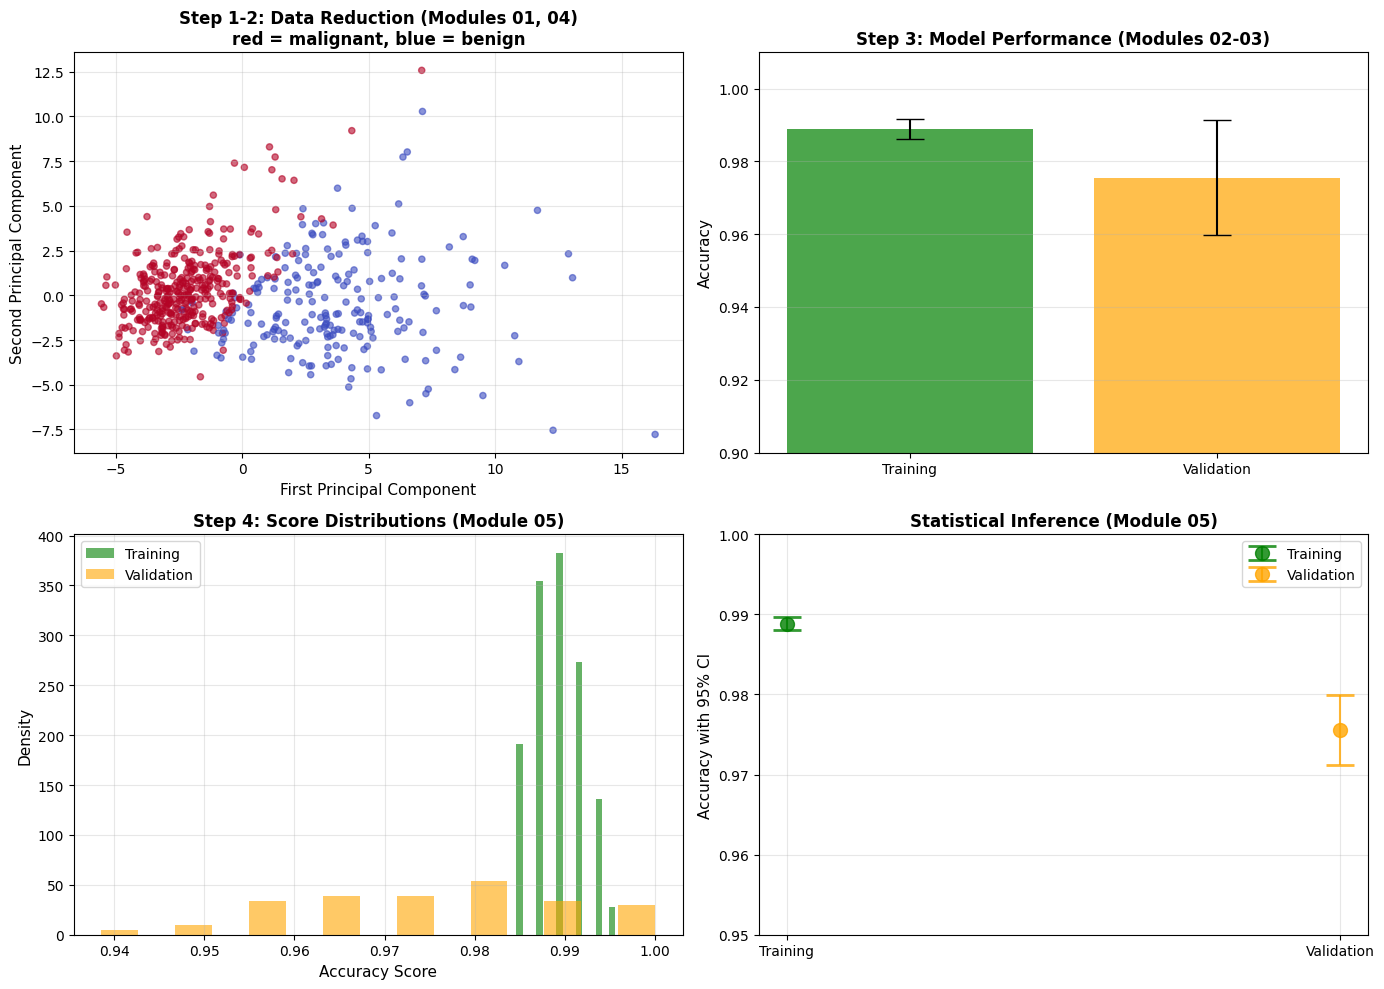


4. Module 05 (Statistical Inference):
 t-test (train vs validation): t = 5.1944, p = 3.959e-06
 ⚠️ The training/validation gap is statistically real - the model fits its
    training folds better than new data, which is what overfitting looks like.
    Here the gap is small in size, so it is worth noting, not alarming.
 95% CI Training: [98.81%, 98.96%]
 95% CI Validation: [97.12%, 97.99%]
 Caveat a careful analyst states: cross-validation folds share data, so these
 scores are not fully independent and the p-value is optimistic. Treat it as a
 strong hint, not a courtroom proof.

📊 Visual Summary:
 Top-left: Data reduction (Modules 01, 04)
 Top-right: Model performance (Modules 02-03)
 Bottom-left: Score distributions (Module 05)
 Bottom-right: Confidence intervals (Module 05)

🎉 All 5 modules working together on one real dataset!


In [4]:
# Interactive Example: Complete ML Pipeline Using All Modules
# VISUAL: See how all modules work together with statistical analysis - on real data end to end.

import numpy as np
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt

print("🎓 Complete ML Workflow - All Modules Together:")
print("=" * 60)

# Step 1: Data representation (Module 01)
# 569 real breast-tumour biopsies, 30 standardized measurements each.
data = StandardScaler().fit_transform(cancer.data)
labels = cancer.target
print("\n1. Module 01 (Linear Algebra):")
print(f" Data represented as matrix: {data.shape}")
print(" Each row is a real biopsy; each column a measurement")

# Step 2: Dimensionality reduction (Module 01 + 03 + 04)
pca = PCA(n_components=5)
data_reduced = pca.fit_transform(data)
print("\n2. Module 04 (Dimensionality Reduction):")
print(f" Reduced to: {data_reduced.shape}")
print(f" Variance kept by those 5 components: {pca.explained_variance_ratio_.sum():.1%}")
print(" Uses eigenvalues (Module 01) + optimization (Module 03)")

# Step 3: Model training (Module 02 + 03) - real fits, real scores
cv50 = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=1)
results = cross_validate(clf, cancer.data, cancer.target, cv=cv50, return_train_score=True)
train_scores = results["train_score"]
val_scores = results["test_score"]

print("\n3. Modules 02-03 (Calculus + Optimization):")
print(" Logistic regression is fitted by gradient-based optimization (Module 03,")
print(" which uses the gradients from Module 02)")
print(f" Training: {np.mean(train_scores):.2%} ± {np.std(train_scores):.2%}")
print(f" Validation: {np.mean(val_scores):.2%} ± {np.std(val_scores):.2%}")

# Step 4: Statistical evaluation (Module 03 + 05)
# Paired test: each training score and validation score come from the SAME split,
# so they are matched pairs - ttest_rel, not ttest_ind.
t_stat, p_value = stats.ttest_rel(train_scores, val_scores)

# Visualize the complete pipeline
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Plot 1: Data reduction, coloured by the real diagnosis
axes[0, 0].scatter(data_reduced[:, 0], data_reduced[:, 1], alpha=0.6,
                   c=labels, cmap='coolwarm', s=20)
axes[0, 0].set_xlabel('First Principal Component', fontsize=11)
axes[0, 0].set_ylabel('Second Principal Component', fontsize=11)
axes[0, 0].set_title('Step 1-2: Data Reduction (Modules 01, 04)\nred = malignant, blue = benign',
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Model performance
axes[0, 1].bar(['Training', 'Validation'],
               [np.mean(train_scores), np.mean(val_scores)],
               yerr=[np.std(train_scores), np.std(val_scores)],
               color=['green', 'orange'], alpha=0.7, capsize=10)
axes[0, 1].set_ylabel('Accuracy', fontsize=11)
axes[0, 1].set_title('Step 3: Model Performance (Modules 02-03)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_ylim(0.90, 1.01)

# Plot 3: Score distributions
axes[1, 0].hist(train_scores, bins=15, alpha=0.6, color='green', label='Training', density=True)
axes[1, 0].hist(val_scores, bins=15, alpha=0.6, color='orange', label='Validation', density=True)
axes[1, 0].set_xlabel('Accuracy Score', fontsize=11)
axes[1, 0].set_ylabel('Density', fontsize=11)
axes[1, 0].set_title('Step 4: Score Distributions (Module 05)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Confidence intervals
means = [np.mean(train_scores), np.mean(val_scores)]
stds = [np.std(train_scores), np.std(val_scores)]
n = len(train_scores)
ci_lower = [m - 1.96 * s / np.sqrt(n) for m, s in zip(means, stds)]
ci_upper = [m + 1.96 * s / np.sqrt(n) for m, s in zip(means, stds)]

axes[1, 1].errorbar(['Training'], [means[0]],
                    yerr=[[means[0] - ci_lower[0]], [ci_upper[0] - means[0]]],
                    fmt='o', capsize=10, capthick=2, markersize=10,
                    color='green', alpha=0.8, label='Training')
axes[1, 1].errorbar(['Validation'], [means[1]],
                    yerr=[[means[1] - ci_lower[1]], [ci_upper[1] - means[1]]],
                    fmt='o', capsize=10, capthick=2, markersize=10,
                    color='orange', alpha=0.8, label='Validation')
axes[1, 1].set_ylabel('Accuracy with 95% CI', fontsize=11)
axes[1, 1].set_title('Statistical Inference (Module 05)', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0.95, 1.0)

plt.tight_layout()
plt.show()

print("\n4. Module 05 (Statistical Inference):")
print(f" t-test (train vs validation): t = {t_stat:.4f}, p = {p_value:.3e}")
if p_value < 0.05:
    print(" ⚠️ The training/validation gap is statistically real - the model fits its")
    print("    training folds better than new data, which is what overfitting looks like.")
    print("    Here the gap is small in size, so it is worth noting, not alarming.")
else:
    print(" ✅ No detectable train/validation gap - good generalization!")
print(f" 95% CI Training: [{ci_lower[0]:.2%}, {ci_upper[0]:.2%}]")
print(f" 95% CI Validation: [{ci_lower[1]:.2%}, {ci_upper[1]:.2%}]")
print(" Caveat a careful analyst states: cross-validation folds share data, so these")
print(" scores are not fully independent and the p-value is optimistic. Treat it as a")
print(" strong hint, not a courtroom proof.")
print("\n📊 Visual Summary:")
print(" Top-left: Data reduction (Modules 01, 04)")
print(" Top-right: Model performance (Modules 02-03)")
print(" Bottom-left: Score distributions (Module 05)")
print(" Bottom-right: Confidence intervals (Module 05)")
print("\n🎉 All 5 modules working together on one real dataset!")


Example: Visualizing Probability Distributions and Statistical Inference
This demonstrates HOW to visualize and interpret statistical concepts



### Best Practices

**Best Practices for Statistical Inference in ML:**

- **Choose Appropriate Tests**: Use t-test for comparing means, chi-square for categorical data, ANOVA for multiple groups
- **Set Significance Level**: Use α=0.05 (95% confidence) as standard, but adjust based on your domain (e.g., medical research may use α=0.01)
- **Report Confidence Intervals**: Always report confidence intervals along with point estimates to show uncertainty
- **Check Assumptions**: Verify test assumptions (normality, independence, equal variances) before running statistical tests
- **Multiple Comparisons**: Use Bonferroni correction or FDR when testing multiple hypotheses to avoid false discoveries
- **Sample Size Matters**: Ensure adequate sample size for reliable statistical inference (use power analysis if needed)

---

# Part 3: AFTER

## Analyzing Results and Understanding Implications

### What Happens Next?

After understanding probabilities and statistical inference:

- **Confident Predictions**: You can quantify uncertainty in model predictions
- **Model Evaluation**: You can statistically compare different models
- **Decision Making**: You can make informed decisions based on statistical evidence
- **Advanced ML**: You're ready for probabilistic ML models (Bayesian methods, etc.)

### How This Connects to Machine Learning

- **Uncertainty Quantification**: Understanding prediction confidence
- **Model Selection**: Statistical tests help choose the best model
- **A/B Testing**: Statistical inference for production model comparisons
- **Bayesian ML**: Foundation for probabilistic machine learning methods


> 💡 **Key Insight**: Statistical inference transforms ML from "the model says X" to "the model says X, and here is the interval around it and the method that produced it." Say it precisely: *"a 95% confidence interval, meaning that if we repeated this experiment many times, 95% of the intervals built this way would contain the true value."* Notebook 08 shows why the shorter, more natural sentence — "we're 95% confident the true value is between Y and Z" — is the one that gets people into trouble. Quantified uncertainty is what makes a model output usable for a real-world decision; a mis-stated interval is what makes it indefensible.


AFTER: Understanding the Impact of Statistical Inference



1. Model Performance Analysis (100 real cross-validation splits):
 Mean accuracy: 0.9765
 Standard deviation: 0.0145
 95% Confidence Interval: [0.9736, 0.9793]

2. Statistical Significance Test:
 Baseline = always predict the majority class: 0.6274 accuracy
 Testing if the model (mean=0.9765) beats that baseline
 t-statistic: 239.8786
 p-value: 1.075e-138
 ✅ Model is significantly better than baseline! (p < 0.05)


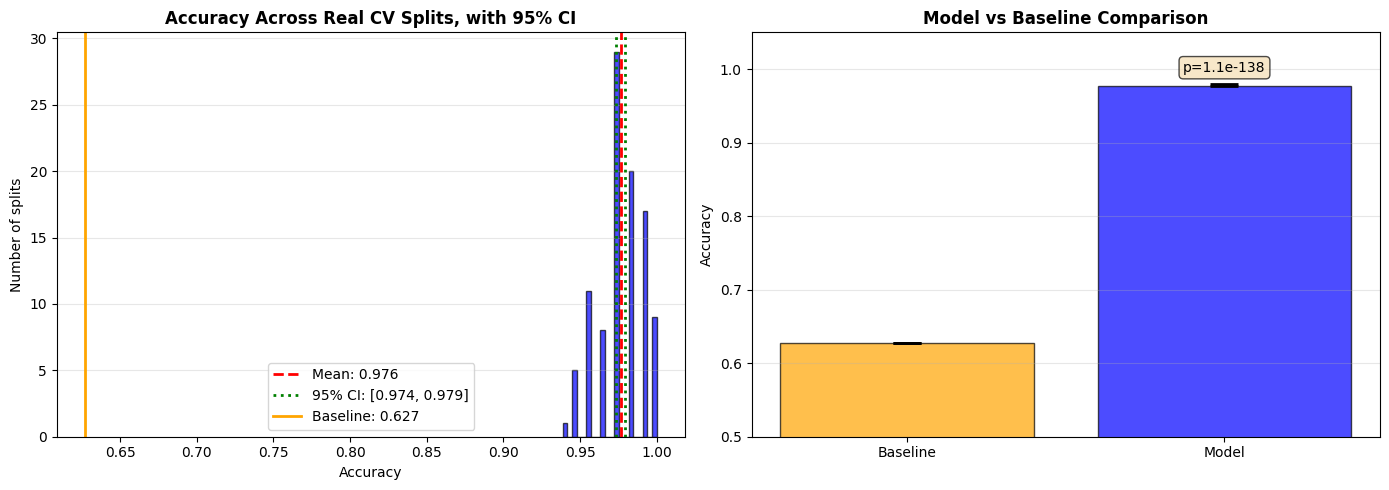


3. Key Insights:
 ✅ Quantified uncertainty in performance
 ✅ Statistically compared model to a real baseline
 ✅ Made a data-driven decision about model performance
 ✅ The model beats the majority-class baseline by 34.9% - and the interval shows that margin is not noise

4. Implications for Machine Learning:
 📊 Uncertainty Quantification: Know how confident we are in predictions
 🎯 Model Selection: Use statistical tests to choose best model
 🔬 A/B Testing: Compare models in production using statistical inference
 📈 Decision Making: Make informed decisions based on statistical evidence
 🧠 Bayesian ML: Foundation for probabilistic machine learning methods

5. When to Use Statistical Inference:
 ✅ Comparing different models
 ✅ Evaluating model improvements
 ✅ Quantifying prediction uncertainty
 ✅ Making production deployment decisions
 ✅ Understanding model reliability

💡 Remember: Statistical inference helps make data-driven decisions!
 Always quantify uncertainty and test significance b

In [5]:
# Example: Analyzing Results and Understanding Implications
# This demonstrates what happens AFTER applying statistical inference - to real measurements.

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier

print("=" * 60)
print("AFTER: Understanding the Impact of Statistical Inference")
print("=" * 60)

# Real model evaluation results: the 100 cross-validation accuracies from Model A.
model_predictions = model_a_scores

# The baseline any classifier must beat: always predict the majority class.
# Its accuracy is not a guess either - it is measured on the same splits.
baseline_scores = cross_val_score(DummyClassifier(strategy="most_frequent"),
                                  cancer.data, cancer.target, cv=cv)
baseline = baseline_scores.mean()

# Calculate metrics
mean_pred = np.mean(model_predictions)
std_pred = np.std(model_predictions)
ci_95 = stats.t.interval(0.95, len(model_predictions) - 1,
                         loc=mean_pred, scale=stats.sem(model_predictions))
print(f"\n1. Model Performance Analysis ({len(model_predictions)} real cross-validation splits):")
print(f" Mean accuracy: {mean_pred:.4f}")
print(f" Standard deviation: {std_pred:.4f}")
print(f" 95% Confidence Interval: [{ci_95[0]:.4f}, {ci_95[1]:.4f}]")

# Statistical test: Is model significantly different from baseline?
t_stat, p_value = stats.ttest_1samp(model_predictions, baseline)

print(f"\n2. Statistical Significance Test:")
print(f" Baseline = always predict the majority class: {baseline:.4f} accuracy")
print(f" Testing if the model (mean={mean_pred:.4f}) beats that baseline")
print(f" t-statistic: {t_stat:.4f}")
print(f" p-value: {p_value:.3e}")
if p_value < 0.05:
    print(f" ✅ Model is significantly better than baseline! (p < 0.05)")
else:
    print(f" ❌ No significant improvement over baseline (p >= 0.05)")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Distribution of fold accuracies with CI
axes[0].hist(model_predictions, bins=20, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(mean_pred, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_pred:.3f}')
axes[0].axvline(ci_95[0], color='green', linestyle=':', linewidth=2,
                label=f'95% CI: [{ci_95[0]:.3f}, {ci_95[1]:.3f}]')
axes[0].axvline(ci_95[1], color='green', linestyle=':', linewidth=2)
axes[0].axvline(baseline, color='orange', linestyle='-', linewidth=2, label=f'Baseline: {baseline:.3f}')
axes[0].set_title('Accuracy Across Real CV Splits, with 95% CI', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].set_ylabel('Number of splits')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Comparison with baseline
axes[1].bar(['Baseline', 'Model'], [baseline, mean_pred],
            yerr=[[0, 0], [0, ci_95[1] - mean_pred]],
            color=['orange', 'blue'], alpha=0.7, capsize=10,
            error_kw={'capthick': 2}, edgecolor='black')
axes[1].set_title('Model vs Baseline Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.05)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].text(1, mean_pred + 0.02, f'p={p_value:.1e}', ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
plt.tight_layout()
plt.show()

print("\n3. Key Insights:")
print(" ✅ Quantified uncertainty in performance")
print(" ✅ Statistically compared model to a real baseline")
print(" ✅ Made a data-driven decision about model performance")
print(f" ✅ The model beats the majority-class baseline by "
      f"{mean_pred - baseline:.1%} - and the interval shows that margin is not noise")

print("\n4. Implications for Machine Learning:")
print(" 📊 Uncertainty Quantification: Know how confident we are in predictions")
print(" 🎯 Model Selection: Use statistical tests to choose best model")
print(" 🔬 A/B Testing: Compare models in production using statistical inference")
print(" 📈 Decision Making: Make informed decisions based on statistical evidence")
print(" 🧠 Bayesian ML: Foundation for probabilistic machine learning methods")

print("\n5. When to Use Statistical Inference:")
print(" ✅ Comparing different models")
print(" ✅ Evaluating model improvements")
print(" ✅ Quantifying prediction uncertainty")
print(" ✅ Making production deployment decisions")
print(" ✅ Understanding model reliability")

print("\n" + "=" * 60)
print("💡 Remember: Statistical inference helps make data-driven decisions!")
print(" Always quantify uncertainty and test significance before deploying models.")
print("=" * 60)


---

## ⚠️ Where this breaks

- **The notebook's own first interval is impossible, and it says so.** Five cross-validation folds gave
  accuracies [0.9561, 0.9737, 0.9825, 1.0000, 0.9823], mean 0.9789, and "mean ± 1.96σ" produces
  **[0.9510, 1.0068]** — an upper bound above 1.0, which no accuracy can reach. With five numbers the
  normal approximation is simply too crude. That is not a typo in the lesson; it is the lesson.
- **Cross-validation folds are not independent, so the p-values here are optimistic.** The comparison of
  logistic regression (0.9765) against Gaussian naive Bayes (0.9384) returns t = 14.39, p = 1.36 × 10⁻³²
  — a number small enough to look like proof. But every fold shares training rows with every other fold, so
  the scores are correlated and the standard t-test's independence assumption is violated. The notebook
  states this explicitly: "treat it as a strong hint, not a courtroom proof." The correct tools are
  corrected resampled t-tests or nested cross-validation (Course 04, Unit 2).
- **A statistically significant difference need not be a useful one.** The gap between train (98.88%) and
  validation (97.56%) accuracy is real at p = 3.96 × 10⁻⁶ *and* it is 1.3 percentage points. With 100 folds
  you can detect differences far too small to act on. Always report the effect size beside the p-value.
- **All of this assumes the 569 biopsies represent the patients you will see.** No confidence interval
  covers a sampling problem. That is notebook 05.


---

## 💬 Discuss

1. Google Flu Trends produced fast, cheap, apparently accurate estimates for several years before failing.
   If you had been reviewing it in 2010, what would you have asked for that would have exposed the problem
   early?
2. The notebook prints a confidence interval whose upper end is above 100% accuracy. Is that a bug in the
   code, a bug in the method, or a bug in how it was reported? Say what you would change, and why.
3. p = 1.36 × 10⁻³² for a 3.8-point accuracy difference, from folds that share data. Write the sentence
   about that comparison you would be willing to defend in front of a statistician.


### Common Pitfalls and How to Avoid Them

**Common Pitfalls and How to Avoid Them:**

1. **P-Value Misinterpretation**: Treating p-value as probability that null hypothesis is true
   - **Solution**: Remember a p-value is the probability of data **at least this extreme** given the null hypothesis is true - not the probability the null is true, and not the probability the result came from chance alone (ASA, 2016)

2. **Multiple Testing Without Correction**: Running many tests increases chance of false positives
   - **Solution**: Use Bonferroni correction, FDR, or other multiple comparison corrections when testing multiple hypotheses

3. **Ignoring Effect Size**: Focusing only on statistical significance without considering practical importance
   - **Solution**: Always report effect size (Cohen's d, correlation coefficient) along with p-values

4. **Data Dredging**: Testing many hypotheses and only reporting significant ones (p-hacking)
   - **Solution**: Pre-specify hypotheses before data collection, use cross-validation, and report all tests performed

### Advanced Topics

**Advanced Topics for Further Learning:**

- **Bayesian Inference**: Updating beliefs with data using Bayes' theorem for probabilistic reasoning
- **Bootstrap Methods**: Resampling techniques for estimating confidence intervals without distribution assumptions
- **Monte Carlo Methods**: Simulation-based inference for complex probabilistic models
- **Hierarchical Models**: Multi-level statistical models for nested or grouped data structures
- **Causal Inference**: Methods for determining cause-and-effect relationships beyond correlation

---

# Summary

## Key Takeaways

## Key Takeaways

In this final module, you've learned how to make data-driven decisions and quantify uncertainty in machine learning:

1. **Probability Theory**: You discovered that probability distributions (normal, binomial, Poisson) model uncertainty in ML. They help you understand prediction confidence, model variability, and data characteristics. Probability is the language of uncertainty, essential for making informed decisions from model outputs.

2. **Statistical Inference**: You learned to go beyond point estimates (single numbers) to understand ranges and confidence. Confidence intervals show a range of plausible values for a population parameter, and the 95% describes the **procedure**: repeated many times, 95% of the intervals built this way would contain the true value (notebook 08 shows why "we're 95% confident the true value is in *this* range" is the wrong sentence). Statistical tests (t-test, chi-square) help determine if differences between models are real or due to chance, guiding model selection decisions.

3. **Sampling**: You understood that we can't use all data - we need representative samples. Random sampling ensures train/test splits are representative. Cross-validation uses multiple train/test splits for more reliable estimates. Bootstrap methods resample data to estimate confidence intervals. Proper sampling is crucial for reliable model evaluation.

4. **Hypothesis Testing**: You learned the framework for validating model improvements: formulate null hypothesis (no difference), compute test statistic, calculate p-value (the probability of data at least this extreme if the null is true - never the probability that the null is true), and make decision (reject null if p < significance level, typically 0.05). This prevents claiming improvements that are just due to random variation.

## 🔗 How This Connects to Other Modules

**What you learned here integrates:**

- **Module 01**: Data representation as vectors/matrices for probabilistic models
- **Module 03**: Statistical foundations → Extended to **statistical inference** (this module)
- **Module 04**: Evaluating reduced-dimensional representations statistically

> 💡 **The Complete Journey**: 
> - Module 01: Data representation (the foundation)
> - Module 02: Compute gradients (the tool for optimization)
> - Module 03: Use gradients for optimization + statistical foundations (the method)
> - Module 04: Reduce dimensions efficiently (the preprocessing)
> - Module 05: Evaluate and make predictions with confidence (the validation) ← **You are here!**

**You've now completed the full mathematical foundation for machine learning!**

## Next Steps

1. Complete the exercises in the `exercises/` folder
2. Review the solutions if needed
3. **Congratulations!** You've completed all 5 modules of Mathematics and Probabilities for ML
4. Apply these concepts to real ML projects
5. Explore advanced topics in probabilistic ML (Bayesian methods, MCMC, etc.)

---

**Ready for exercises?** Navigate to the `exercises/` folder and start practicing!

## 📚 References

1. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Ch. 1–2. Springer.
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 3: Probability and Information Theory. MIT Press. <https://www.deeplearningbook.org/>
3. Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. <https://probml.github.io/pml-book/book1.html>
4. Angelopoulos & Bates (2022). *A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification*. arXiv. <https://arxiv.org/abs/2107.07511> — distribution-free prediction sets with a coverage guarantee: the ML-facing payoff of this module.
5. Liu, X., Chen, T., Da, L., Chen, C., Lin, Z., & Wei, H. (2025). *Uncertainty Quantification and Confidence Calibration in Large Language Models: A Survey*. arXiv. <https://arxiv.org/abs/2503.15850> — how uncertainty is estimated for large models in 2025, and where the classical methods stop working.
